# Notebook 3 — 2D Consolidation FEM Verification

This notebook runs the 2D FEM consolidation solver and checks it against the analytical Boussinesq initial condition.

Checks:

1. **Initial pore-pressure check** — FEM u₀ at every mesh node must match the analytical Boussinesq u₀ field. Maximum and RMS differences are reported.
2. **Pore-pressure contour plots** — visual inspection at t = 0 and a mid-time snapshot.
3. **Surface settlement profile** — settlement across the surface width at several times.

A single uniform layer is used here to keep the first verification as simple as possible. Layered examples follow at the end.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

import os, sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

from src.geotech_consolidation.models.terzaghi_2d.fem import Get_terzaghi2D_FEA


H = 5.0        
W = H           
nx  = 25           
load = 100.0        # kPa
base  = 2.0     
final_time          = 3650 * 24 * 60 * 60   # 10 years total time (s)
time_steps = 500

Cv_val     = 2e-7         # coefficient of consolidation (m²/s)
Mv_val     = 5e-4         # coefficient of volume compressibility (m²/kN)

time_days  = np.linspace(0, final_time / (60 * 60 * 24), time_steps)

# --- Permeability from Cv ---
# k = Cv * Mv * γw
gamma_w = 9.81   # unit weight of water (kN/m³)
k = Cv_val * Mv_val * gamma_w
print(f"Cv = {Cv_val:.2e} m²/s")
print(f"k  = {k:.2e} m/s   (k = Cv · Mv · γw)")

Cv = 2.00e-07 m²/s
k  = 9.81e-10 m/s   (k = Cv · Mv · γw)


## FEM Solve


In [2]:
settlement_surface, total_settlement, u_hist, unique_X, node_X, node_Y = Get_terzaghi2D_FEA(
    H=H, W=W, nx=nx, load=load,
    final_time=final_time, time_steps=time_steps,
    Cv=Cv_val, Mv=Mv_val,
    base=base, depths=None
)

print(f"u_hist shape:          {u_hist.shape}   (time_steps × n_nodes)")
print(f"settlement_surface:    {settlement_surface.shape}  (time_steps × nX)")
print(f"unique_X range:        [{unique_X.min():.1f}, {unique_X.max():.1f}] m")
print(f"Max pore pressure:     {u_hist.max():.2f} kPa")
print(f"Max settlement:        {settlement_surface.max() * 1000:.2f} mm")

u_hist shape:          (500, 676)   (time_steps × n_nodes)
settlement_surface:    (500, 26)  (time_steps × nX)
unique_X range:        [-5.0, 5.0] m
Max pore pressure:     99.60 kPa
Max settlement:        128.85 mm


## Pore-Pressure Contours Through Time

Contour plots at t = 0 and a mid-time snapshot confirm the field is dissipating physically.


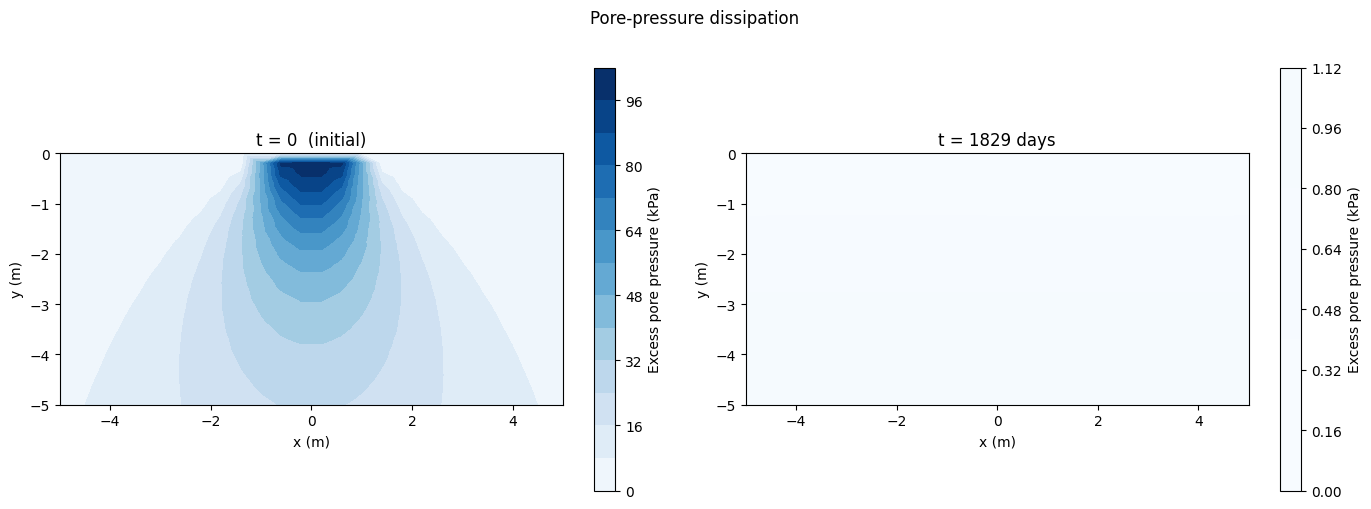

In [3]:
t_mid   = time_steps // 2
triang  = tri.Triangulation(node_X, node_Y)
vmax    = u_hist[0, :].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ti, label in zip(
    axes,
    [0, t_mid],
    ["t = 0  (initial)", f"t = {time_days[t_mid]:.0f} days"]
):
    cf = ax.tricontourf(triang, u_hist[ti, :], levels=15, cmap="Blues", vmin=0, vmax=vmax)
    plt.colorbar(cf, ax=ax, label="Excess pore pressure (kPa)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(label)
    ax.set_aspect("equal")

plt.suptitle("Pore-pressure dissipation", y=1.01)
plt.tight_layout()
plt.show()

## Centreline Pore Pressure Profile (x ≈ 0)

Vertical profiles extracted at the column nearest to x = 0 (directly beneath the load centre) at several time snapshots.  This is the 2D analogue of the 1D depth profiles and makes the two results directly comparable: in 1D the only drainage path is vertical; here the same column is additionally relieved by lateral drainage toward the free edges, so excess pressure should dissipate faster at mid-depth.

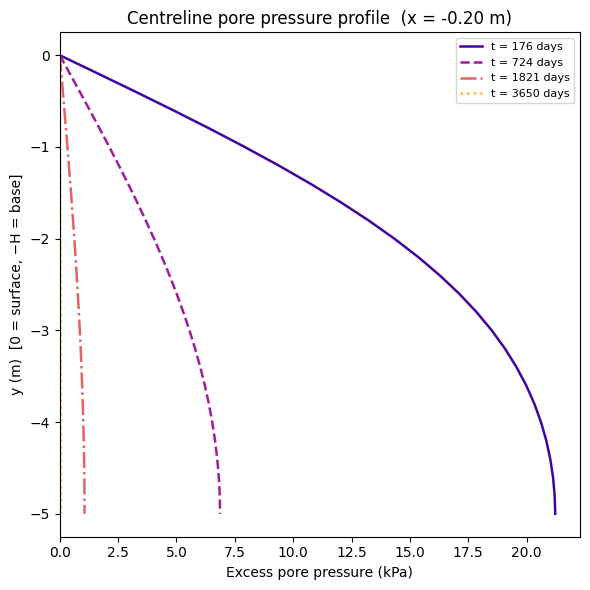

In [4]:
# --- Centreline column: node column closest to x = 0 ---
x_cl   = unique_X[np.argmin(np.abs(unique_X))]          # x of nearest column to x=0
dx_half = np.min(np.diff(unique_X)) * 0.5               # half x-spacing as tolerance
cl_mask  = np.abs(node_X - x_cl) < dx_half
cl_idx   = np.where(cl_mask)[0]
cl_sort  = np.argsort(node_Y[cl_idx])[::-1]             # surface (y=0) first
cl_nodes = cl_idx[cl_sort]
cl_y     = node_Y[cl_nodes]                             # y: 0 (surface) → -H (base)

fracs      = [0.05, 0.2, 0.5, 1.0]
colours    = plt.cm.plasma(np.linspace(0.1, 0.85, len(fracs)))
linestyles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(figsize=(6, 6))
for ls, col, frac in zip(linestyles, colours, fracs):
    ti    = int(frac * (time_steps - 1))
    label = f"t = {time_days[ti]:.0f} days"
    ax.plot(u_hist[ti, cl_nodes], cl_y, color=col, linestyle=ls, linewidth=1.8, label=label)

ax.set_xlabel("Excess pore pressure (kPa)")
ax.set_ylabel("y (m)  [0 = surface, −H = base]")
ax.set_title(f"Centreline pore pressure profile  (x = {x_cl:.2f} m)")
ax.legend(fontsize=8)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## Darcy Flux — Lateral Drainage Component

The Darcy flux **q** = −(k/γw) ∇u is computed element-wise from the linear shape-function gradients (exact within each triangle).  The magnitude contour shows where flow is most intense; the normalised arrows show the flow direction.  Near the loaded region centre the flow is predominantly vertical (same as 1D); approaching the free lateral boundaries a horizontal component develops — this is the feature absent from a 1D model.

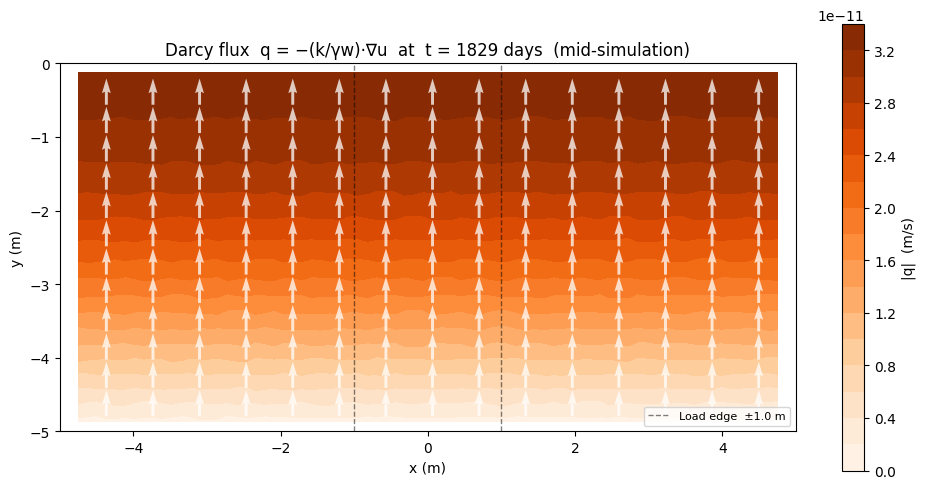

In [5]:
from scipy.interpolate import griddata

t_flux = time_steps // 2   # mid-simulation snapshot

# --- Element-wise exact gradient from linear triangle shape functions ---
tris   = triang.triangles                        # (n_tri, 3) node indices
xv = node_X[tris]; yv = node_Y[tris]
uv = u_hist[t_flux, tris]

xc = xv.mean(axis=1)                            # element centroids
yc = yv.mean(axis=1)

# Solve  [xj-xi  xk-xi] [du/dx]   [uj-ui]
#        [yj-yi  yk-yi] [du/dy] = [uk-ui]
dx_ji = xv[:,1] - xv[:,0];  dx_ki = xv[:,2] - xv[:,0]
dy_ji = yv[:,1] - yv[:,0];  dy_ki = yv[:,2] - yv[:,0]
du_ji = uv[:,1] - uv[:,0];  du_ki = uv[:,2] - uv[:,0]
det   = dx_ji * dy_ki - dx_ki * dy_ji
dudx  = (du_ji * dy_ki - du_ki * dy_ji) / det
dudy  = (dx_ji * du_ki - dx_ki * du_ji) / det

k_over_gw = k / gamma_w                         # m²/(s·kPa) — hydraulic conductivity scaled
qx_el = -k_over_gw * dudx                       # Darcy flux components (m/s)
qy_el = -k_over_gw * dudy
q_mag  = np.hypot(qx_el, qy_el)

# --- Interpolate to regular grid for contourf ---
n_xi, n_yi = 80, 40
xi = np.linspace(-W, W, n_xi)
yi = np.linspace(-H, 0.0, n_yi)
Xi, Yi = np.meshgrid(xi, yi)
pts = np.column_stack([xc, yc])

q_grid  = griddata(pts, q_mag,  (Xi, Yi), method="linear")
qx_grid = griddata(pts, qx_el, (Xi, Yi), method="linear")
qy_grid = griddata(pts, qy_el, (Xi, Yi), method="linear")

# Normalise arrows so all have equal length (direction only)
q_norm = np.hypot(qx_grid, qy_grid)
with np.errstate(invalid="ignore"):
    qx_dir = np.where(q_norm > 0, qx_grid / q_norm, 0.0)
    qy_dir = np.where(q_norm > 0, qy_grid / q_norm, 0.0)

fig, ax = plt.subplots(figsize=(10, 5))
cf = ax.contourf(Xi, Yi, q_grid, levels=15, cmap="Oranges")
plt.colorbar(cf, ax=ax, label="|q|  (m/s)")

sx, sy = 5, 3                                    # quiver subsample strides
ax.quiver(
    Xi[::sy, ::sx], Yi[::sy, ::sx],
    qx_dir[::sy, ::sx], qy_dir[::sy, ::sx],
    color="white", alpha=0.75, pivot="mid",
    scale=28, width=0.004,
)

ax.axvline(-base / 2, color="k", linewidth=1, linestyle="--", alpha=0.5, label=f"Load edge  ±{base/2} m")
ax.axvline( base / 2, color="k", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Darcy flux  q = −(k/γw)·∇u  at  t = {time_days[t_flux]:.0f} days  (mid-simulation)")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## Surface Settlement Profile

Settlement across the surface width at several times.


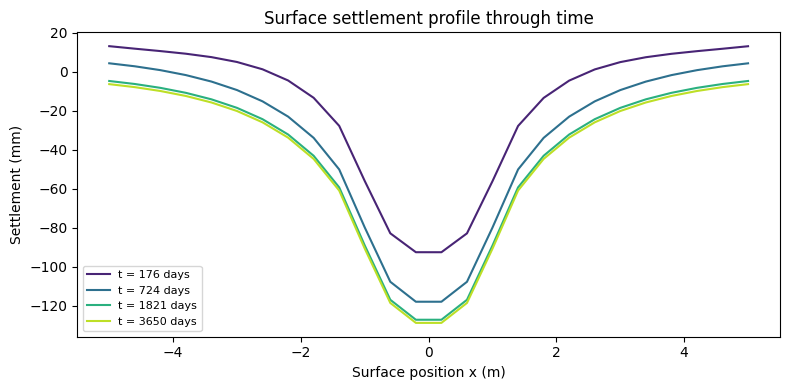

In [6]:
fracs   = [0.05, 0.2, 0.5, 1.0]
colours = plt.cm.viridis(np.linspace(0.1, 0.9, len(fracs)))

fig, ax = plt.subplots(figsize=(8, 4))
for col, frac in zip(colours, fracs):
    ti    = int(frac * (time_steps - 1))
    label = f"t = {time_days[ti]:.0f} days"
    ax.plot(unique_X, -settlement_surface[ti, :] * 1000, color=col, label=label)

ax.set_xlabel("Surface position x (m)")
ax.set_ylabel("Settlement (mm)")
ax.set_title("Surface settlement profile through time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Note — Layered Cv and Mv

To run a layered 2D case, pass `depths`, `Cv`, and `Mv` as lists. Depths are measured downward from y = 0 and apply uniformly across the full width. Example:

```python
depths = [1.5, 3.0, 5.0]
Cv     = [2e-7, 1e-7, 3e-7]
Mv     = [5e-4, 8e-4, 4e-4]

# Permeability per layer
gamma_w = 9.81
k = [Cv_i * Mv_i * gamma_w for Cv_i, Mv_i in zip(Cv, Mv)]
for i, (Cv_i, k_i) in enumerate(zip(Cv, k)):
    print(f"Layer {i+1}: Cv = {Cv_i:.2e} m²/s   k = {k_i:.2e} m/s")

settlement_surface, total_settlement, u_hist, unique_X, node_X, node_Y = Get_terzaghi2D_FEA(
    H=H, W=W, nx=nx, load=load,
    final_time=final_time, time_steps=time_steps,
    Cv=Cv, Mv=Mv, base=base, depths=depths
)
```
